## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
data = load_diabetes()
X = data.data
y = data.target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

In [11]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

In [12]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

In [13]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

rmse_elastic = np.sqrt(mean_squared_error(y_test, pred_elastic))
r2_elastic = r2_score(y_test, pred_elastic)

In [14]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "ElasticNet"],
    "RMSE": [rmse_lin, rmse_ridge, rmse_lasso, rmse_elastic],
    "R2 Score": [r2_lin, r2_ridge, r2_lasso, r2_elastic]
})

results

,Model,RMSE,R2 Score
0,Linear,53.853446,0.452603
1,Ridge,55.474462,0.419153
2,Lasso,52.897954,0.471855
3,ElasticNet,69.104752,0.098654


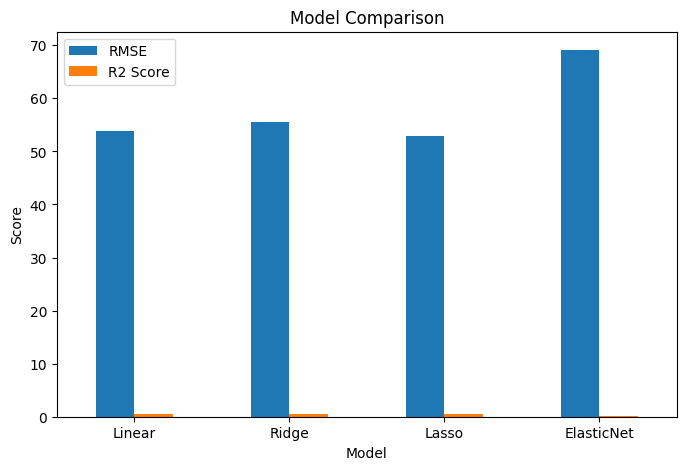

In [15]:
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Conclusion:
In this experiment, different regression models were compared using RMSE and R² score. Regularization techniques like Ridge, Lasso, and ElasticNet helped improve performance by reducing overfitting. The best model is the one with the lowest RMSE and highest R² value.